# Assignment 3 - Demand Unconstraining

In [18]:
import pandas as pd

## Part I: Demand Unconstraining: Physical products with limited inventory

### Setup Data

In [35]:
df_grocery = pd.read_excel('../data/grocery_data.xlsx')

df_grocery

,Unnamed: 0,Hourly interval,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Total
0,Day,1,2,3,4,5,6,7,8,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,NaN
1,1,2,4,4,2,4,2,4,1,5.0,4.0,5.0,3.0,NaN,NaN,NaN,NaN,40.0
2,2,3,4,4,5,4,5,4,2,4.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,40.0
3,3,1,3,2,2,3,6,4,2,3.0,3.0,3.0,4.0,2.0,2.0,NaN,NaN,40.0
4,4,2,3,4,1,4,3,3,1,3.0,3.0,4.0,2.0,3.0,2.0,2.0,NaN,40.0
5,5,2,5,5,3,5,5,5,2,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,40.0
6,6,1,3,3,1,3,3,2,1,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,31.0
7,7,3,4,3,2,4,5,5,3,2.0,4.0,3.0,2.0,NaN,NaN,NaN,NaN,40.0
8,8,1,2,2,1,1,1,2,1,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,20.0
9,9,1,2,3,2,2,2,2,1,2.0,2.0,2.0,2.0,2.0,3.0,2.0,1.0,31.0


In [36]:
# Remove first row and column to only leave data r
df_grocery = df_grocery.iloc[1:,1:]
df_grocery.head(20)

,Hourly interval,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Total
1,2,4,4,2,4,2,4,1,5.0,4.0,5.0,3.0,NaN,NaN,NaN,NaN,40.0
2,3,4,4,5,4,5,4,2,4.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,40.0
3,1,3,2,2,3,6,4,2,3.0,3.0,3.0,4.0,2.0,2.0,NaN,NaN,40.0
4,2,3,4,1,4,3,3,1,3.0,3.0,4.0,2.0,3.0,2.0,2.0,NaN,40.0
5,2,5,5,3,5,5,5,2,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,40.0
6,1,3,3,1,3,3,2,1,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,31.0
7,3,4,3,2,4,5,5,3,2.0,4.0,3.0,2.0,NaN,NaN,NaN,NaN,40.0
8,1,2,2,1,1,1,2,1,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,20.0
9,1,2,3,2,2,2,2,1,2.0,2.0,2.0,2.0,2.0,3.0,2.0,1.0,31.0
10,2,6,6,3,4,2,4,2,6.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,40.0


In [37]:
# rename columns
import numpy as np
df_grocery.columns = np.arange(1,18)
df_grocery = df_grocery.add_prefix("Hour ")
df_grocery.drop(columns=['Hour 17'], inplace=True)
df_grocery.head(20)

,Hour 1,Hour 2,Hour 3,Hour 4,Hour 5,Hour 6,Hour 7,Hour 8,Hour 9,Hour 10,Hour 11,Hour 12,Hour 13,Hour 14,Hour 15,Hour 16
1,2,4,4,2,4,2,4,1,5.0,4.0,5.0,3.0,NaN,NaN,NaN,NaN
2,3,4,4,5,4,5,4,2,4.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN
3,1,3,2,2,3,6,4,2,3.0,3.0,3.0,4.0,2.0,2.0,NaN,NaN
4,2,3,4,1,4,3,3,1,3.0,3.0,4.0,2.0,3.0,2.0,2.0,NaN
5,2,5,5,3,5,5,5,2,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN
6,1,3,3,1,3,3,2,1,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0
7,3,4,3,2,4,5,5,3,2.0,4.0,3.0,2.0,NaN,NaN,NaN,NaN
8,1,2,2,1,1,1,2,1,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0
9,1,2,3,2,2,2,2,1,2.0,2.0,2.0,2.0,2.0,3.0,2.0,1.0
10,2,6,6,3,4,2,4,2,6.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# Convert into gradual summation across the rows (Matching Hyatt data)
df_grocery = df_grocery.cumsum(axis=1)

# Fill NaN's with max value (40.0)
df_grocery = df_grocery.fillna(40.0)
df_grocery

,Hour 1,Hour 2,Hour 3,Hour 4,Hour 5,Hour 6,Hour 7,Hour 8,Hour 9,Hour 10,Hour 11,Hour 12,Hour 13,Hour 14,Hour 15,Hour 16
1,2.0,6.0,10.0,12.0,16.0,18.0,22.0,23.0,28.0,32.0,37.0,40.0,40.0,40.0,40.0,40.0
2,3.0,7.0,11.0,16.0,20.0,25.0,29.0,31.0,35.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0
3,1.0,4.0,6.0,8.0,11.0,17.0,21.0,23.0,26.0,29.0,32.0,36.0,38.0,40.0,40.0,40.0
4,2.0,5.0,9.0,10.0,14.0,17.0,20.0,21.0,24.0,27.0,31.0,33.0,36.0,38.0,40.0,40.0
5,2.0,7.0,12.0,15.0,20.0,25.0,30.0,32.0,36.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0
6,1.0,4.0,7.0,8.0,11.0,14.0,16.0,17.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0,31.0
7,3.0,7.0,10.0,12.0,16.0,21.0,26.0,29.0,31.0,35.0,38.0,40.0,40.0,40.0,40.0,40.0
8,1.0,3.0,5.0,6.0,7.0,8.0,10.0,11.0,12.0,13.0,15.0,16.0,17.0,18.0,19.0,20.0
9,1.0,3.0,6.0,8.0,10.0,12.0,14.0,15.0,17.0,19.0,21.0,23.0,25.0,28.0,30.0,31.0
10,2.0,8.0,14.0,17.0,21.0,23.0,27.0,29.0,35.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0


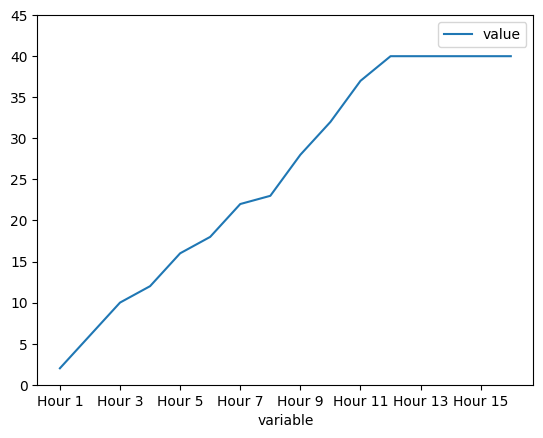

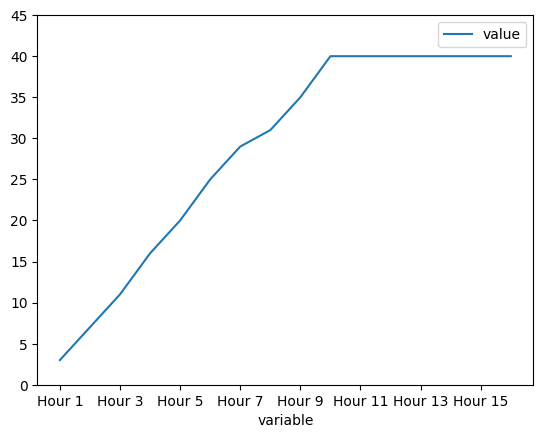

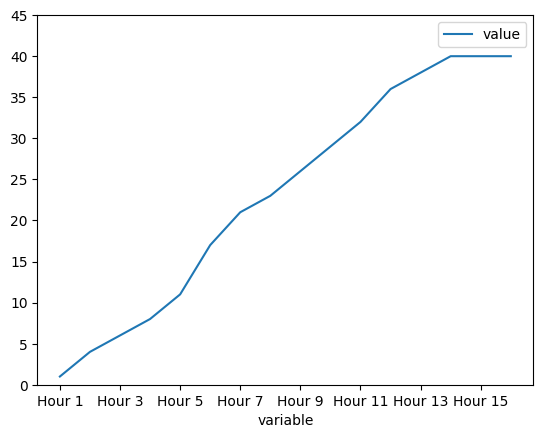

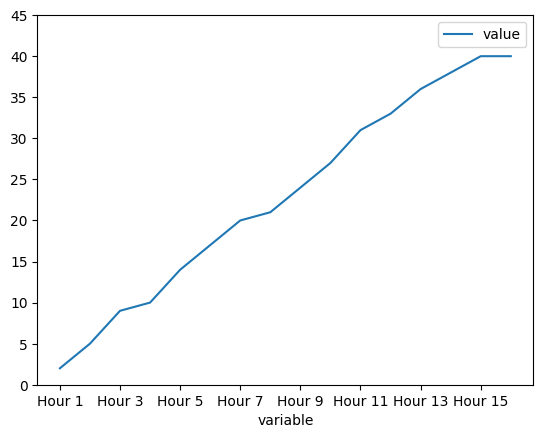

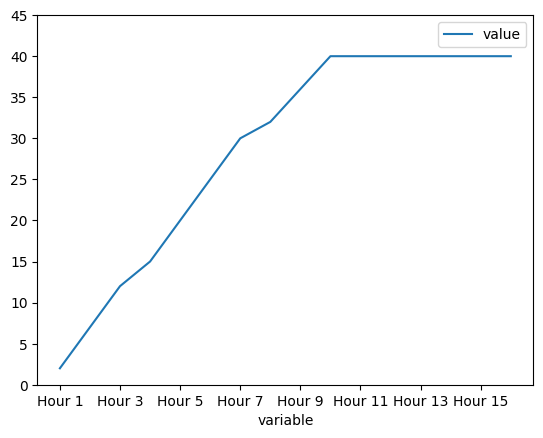

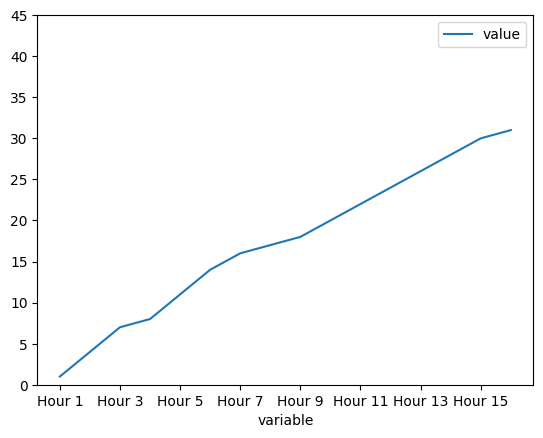

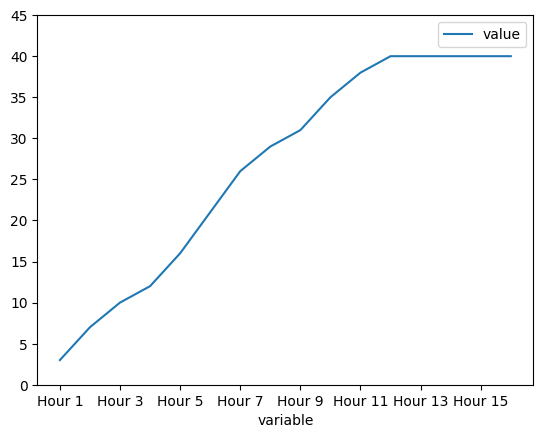

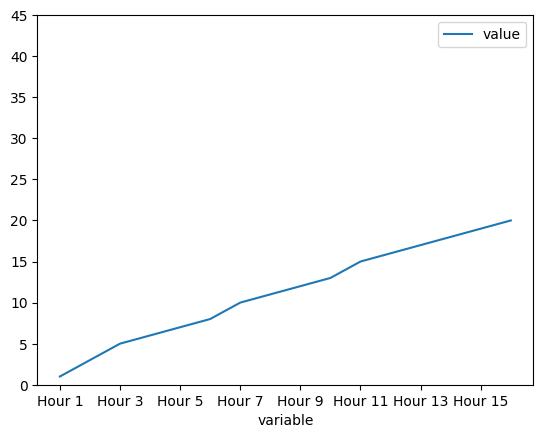

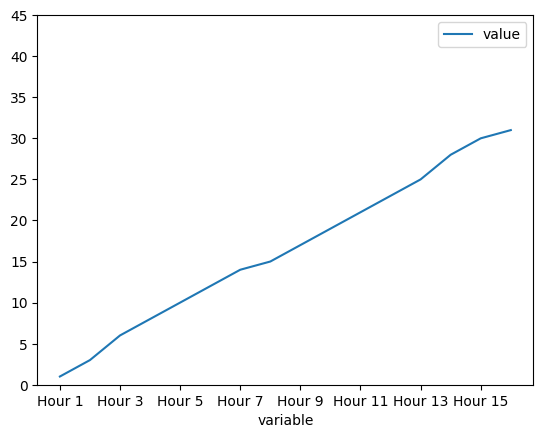

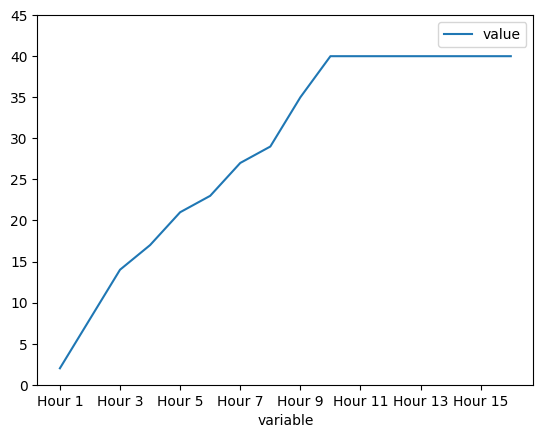

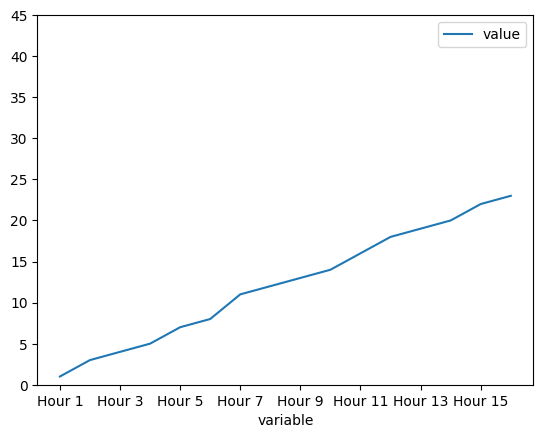

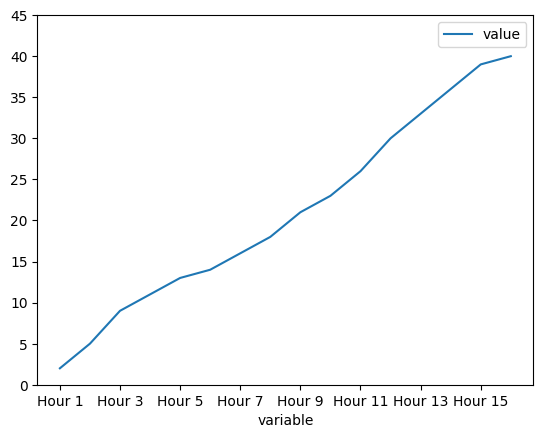

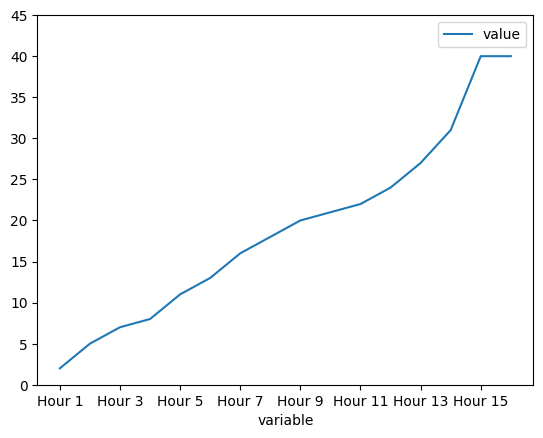

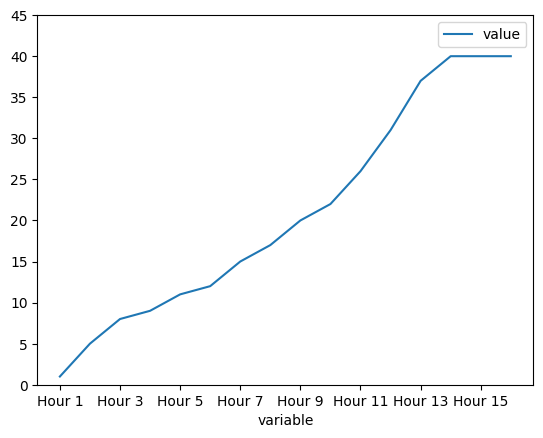

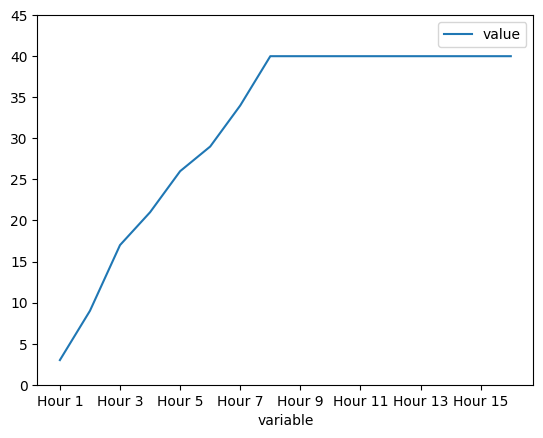

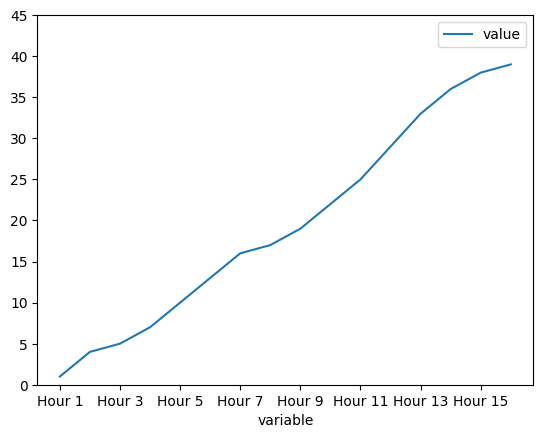

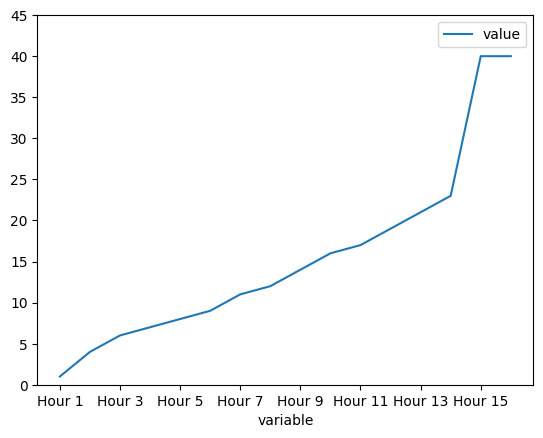

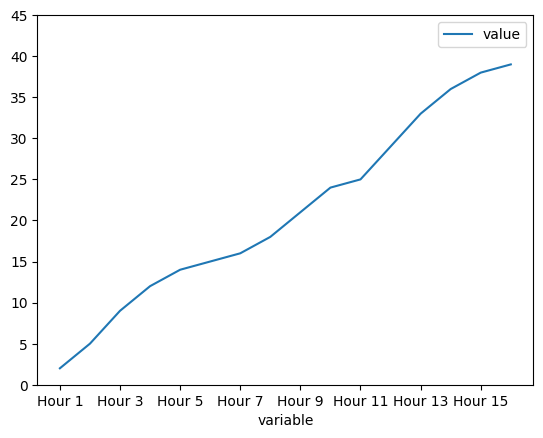

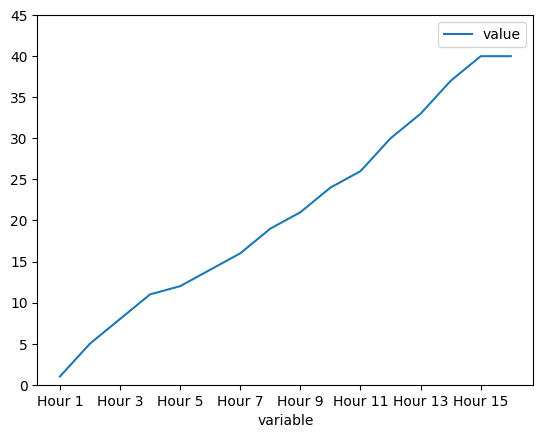

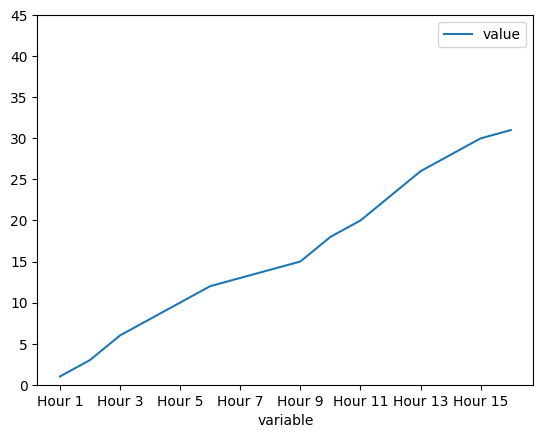

In [40]:
# Eyeball the data (^_^)
df_grocery_ = df_grocery.reset_index()
df_grocery_ = pd.melt(df_grocery_, id_vars=['index'])
booking_plot = df_grocery_.groupby('index').plot(x='variable', y='value', kind='line', ylim=(0,45))

### a) DES Method

In [41]:
# Step 1: Tease out the constrained booking curves - When Hour 16 = 40.0
df_grocery['censored'] = df_grocery['Hour 16'] == 40.0
df_grocery
# now that we have identified the censored curves, we need to uncensor the data

,Hour 1,Hour 2,Hour 3,Hour 4,Hour 5,Hour 6,Hour 7,Hour 8,Hour 9,Hour 10,Hour 11,Hour 12,Hour 13,Hour 14,Hour 15,Hour 16,censored
1,2.0,6.0,10.0,12.0,16.0,18.0,22.0,23.0,28.0,32.0,37.0,40.0,40.0,40.0,40.0,40.0,True
2,3.0,7.0,11.0,16.0,20.0,25.0,29.0,31.0,35.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True
3,1.0,4.0,6.0,8.0,11.0,17.0,21.0,23.0,26.0,29.0,32.0,36.0,38.0,40.0,40.0,40.0,True
4,2.0,5.0,9.0,10.0,14.0,17.0,20.0,21.0,24.0,27.0,31.0,33.0,36.0,38.0,40.0,40.0,True
5,2.0,7.0,12.0,15.0,20.0,25.0,30.0,32.0,36.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True
6,1.0,4.0,7.0,8.0,11.0,14.0,16.0,17.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0,31.0,False
7,3.0,7.0,10.0,12.0,16.0,21.0,26.0,29.0,31.0,35.0,38.0,40.0,40.0,40.0,40.0,40.0,True
8,1.0,3.0,5.0,6.0,7.0,8.0,10.0,11.0,12.0,13.0,15.0,16.0,17.0,18.0,19.0,20.0,False
9,1.0,3.0,6.0,8.0,10.0,12.0,14.0,15.0,17.0,19.0,21.0,23.0,25.0,28.0,30.0,31.0,False
10,2.0,8.0,14.0,17.0,21.0,23.0,27.0,29.0,35.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True


In [42]:
# Step 2: apply DES to the constrained curves; find best alpha and beta for each; predict
## DES method for demand uncensoring
# copy the censored series (rows)

df_des = df_grocery[df_grocery.censored].drop('censored',axis=1)

# replace 25 with NaN, as we will use the unconstrained part of the constrained curves to make our prediction
df_des = df_des.replace(40.0,np.nan)
df_des

,Hour 1,Hour 2,Hour 3,Hour 4,Hour 5,Hour 6,Hour 7,Hour 8,Hour 9,Hour 10,Hour 11,Hour 12,Hour 13,Hour 14,Hour 15,Hour 16
1,2.0,6.0,10.0,12.0,16.0,18.0,22.0,23.0,28.0,32.0,37.0,NaN,NaN,NaN,NaN,NaN
2,3.0,7.0,11.0,16.0,20.0,25.0,29.0,31.0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,4.0,6.0,8.0,11.0,17.0,21.0,23.0,26.0,29.0,32.0,36.0,38.0,NaN,NaN,NaN
4,2.0,5.0,9.0,10.0,14.0,17.0,20.0,21.0,24.0,27.0,31.0,33.0,36.0,38.0,NaN,NaN
5,2.0,7.0,12.0,15.0,20.0,25.0,30.0,32.0,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,3.0,7.0,10.0,12.0,16.0,21.0,26.0,29.0,31.0,35.0,38.0,NaN,NaN,NaN,NaN,NaN
10,2.0,8.0,14.0,17.0,21.0,23.0,27.0,29.0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2.0,5.0,9.0,11.0,13.0,14.0,16.0,18.0,21.0,23.0,26.0,30.0,33.0,36.0,39.0,NaN
13,2.0,5.0,7.0,8.0,11.0,13.0,16.0,18.0,20.0,21.0,22.0,24.0,27.0,31.0,NaN,NaN
14,1.0,5.0,8.0,9.0,11.0,12.0,15.0,17.0,20.0,22.0,26.0,31.0,37.0,NaN,NaN,NaN


In [47]:
# strategy:
# create a big loop that takes a censored curve as input and fills in the nan's
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.api import ExponentialSmoothing
from itertools import product

# write a function that takes alpha,beta,series as input
# and produces the traning sample MSE
# allow 3 periods for burn-in (made shorter since the total data is only 16 hours / day)
def DESMSE(alpha,beta,series):
    return mean_squared_error(series[3:],
                              ExponentialSmoothing(series,trend="add", initialization_method='estimated').fit(smoothing_level = alpha,smoothing_trend = beta).predict(3,series.size-1))

# the function below allows you to construct a dataframe of alpha-beta combinations
def expand_grid(dictionary):
   return pd.DataFrame([row for row in product(*dictionary.values())], 
                       columns=dictionary.keys())

# define the alpha and beta values to try as a dictionary
dictionary = {'alpha': np.arange(0.1, 1.1, 0.1), 
              'beta': np.arange(0.1, 1.1, 0.1)}


# predict curve by curve
# note: the shape attribute for numpy arrays returns the dimensions of the array. If a df has n rows and m columns, then df.shape is (n,m). So Y.shape[0] is n
for row_number in np.arange(0,df_des.shape[0]):
    # take out a censored curve, drop nan values
    temp = df_des.iloc[row_number,:].dropna().reset_index(drop=True)
    
    # convert cumulative booking into daily booking
    # .diff() will work too
    # temp[1:] gets booking vlaues for days 2-40, temp[:-1] gets booking vlaues for days 1-39,
    temp = np.append(temp[0],temp[1:].values - temp[:-1].values)
    
    # construct alpha,beta values to try 
    des_results = expand_grid(dictionary)
    
    # add a column called mse, as a place holder for putting in the MSE results later
    des_results["mse"] = np.repeat(0,len(des_results))
    
    # reuse the DESMSE function above to cycle through all alpha beta values
    # (alpha,beta,series) = (alpha,beta,temp)
    for alpha in np.arange(0.1, 1.1, 0.1):
        for beta in np.arange(0.1, 1.1, 0.1):
           des_results.loc[(des_results["alpha"] == alpha) & (des_results["beta"] == beta),"mse"] = DESMSE(alpha,beta,temp)
    
    # find the best (alpha beta): sort and put on row 1
    des_results = des_results.sort_values("mse")

    # use the best (alpha,beta) to forecast for the censored days
    # post results onto df_des
    # forecast(40-temp.size) ensures that we forecast the censored days
    predicted_hourly_sales = ExponentialSmoothing(temp, trend="add", initialization_method='estimated').fit(smoothing_level = des_results.iloc[0,0], smoothing_trend = des_results.iloc[0,1]).forecast(16-temp.size)
                                            
    # cumsum the daily arrival and add back to the last value that's not nan
    df_des.iloc[row_number,temp.size:] = predicted_hourly_sales.cumsum() + df_des.iloc[row_number,temp.size-1]

/var/folders/ns/52cz2xsx3nv_ncxwvhlz83_m0000gn/T/ipykernel_24087/3400076744.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.880416320939554' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  des_results.loc[(des_results["alpha"] == alpha) & (des_results["beta"] == beta),"mse"] = DESMSE(alpha,beta,temp)
/var/folders/ns/52cz2xsx3nv_ncxwvhlz83_m0000gn/T/ipykernel_24087/3400076744.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.091365699735796' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  des_results.loc[(des_results["alpha"] == alpha) & (des_results["beta"] == beta),"mse"] = DESMSE(alpha,beta,temp)
/var/folders/ns/52cz2xsx3nv_ncxwvhlz83_m0000gn/T/ipykernel_24087/3400076744.py:45: FutureWarning: Setting an item of incompatible dtyp

In [48]:
df_des

,Hour 1,Hour 2,Hour 3,Hour 4,Hour 5,Hour 6,Hour 7,Hour 8,Hour 9,Hour 10,Hour 11,Hour 12,Hour 13,Hour 14,Hour 15,Hour 16
1,2.0,6.0,10.0,12.0,16.0,18.0,22.0,23.000000,28.000000,32.000000,37.000000,41.213765,45.572536,50.076314,54.725098,59.518888
2,3.0,7.0,11.0,16.0,20.0,25.0,29.0,31.000000,35.000000,38.730226,42.425552,46.085979,49.711507,53.302136,56.857866,60.378696
3,1.0,4.0,6.0,8.0,11.0,17.0,21.0,23.000000,26.000000,29.000000,32.000000,36.000000,38.000000,41.484644,45.042991,48.675040
4,2.0,5.0,9.0,10.0,14.0,17.0,20.0,21.000000,24.000000,27.000000,31.000000,33.000000,36.000000,38.000000,40.656035,43.302608
5,2.0,7.0,12.0,15.0,20.0,25.0,30.0,32.000000,36.000000,40.094660,44.204114,48.328362,52.467406,56.621243,60.789876,64.973302
7,3.0,7.0,10.0,12.0,16.0,21.0,26.0,29.000000,31.000000,35.000000,38.000000,41.466845,44.933120,48.398824,51.863958,55.328521
10,2.0,8.0,14.0,17.0,21.0,23.0,27.0,29.000000,35.000000,38.780461,42.540991,46.281589,50.002256,53.702991,57.383794,61.044666
12,2.0,5.0,9.0,11.0,13.0,14.0,16.0,18.000000,21.000000,23.000000,26.000000,30.000000,33.000000,36.000000,39.000000,42.048278
13,2.0,5.0,7.0,8.0,11.0,13.0,16.0,18.000000,20.000000,21.000000,22.000000,24.000000,27.000000,31.000000,33.426479,35.886294
14,1.0,5.0,8.0,9.0,11.0,12.0,15.0,17.000000,20.000000,22.000000,26.000000,31.000000,37.000000,43.031975,50.183874,58.455696


In [50]:
df_grocery[df_grocery.censored == True]

,Hour 1,Hour 2,Hour 3,Hour 4,Hour 5,Hour 6,Hour 7,Hour 8,Hour 9,Hour 10,Hour 11,Hour 12,Hour 13,Hour 14,Hour 15,Hour 16,censored
1,2.0,6.0,10.0,12.0,16.0,18.0,22.0,23.0,28.0,32.0,37.0,40.0,40.0,40.0,40.0,40.0,True
2,3.0,7.0,11.0,16.0,20.0,25.0,29.0,31.0,35.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True
3,1.0,4.0,6.0,8.0,11.0,17.0,21.0,23.0,26.0,29.0,32.0,36.0,38.0,40.0,40.0,40.0,True
4,2.0,5.0,9.0,10.0,14.0,17.0,20.0,21.0,24.0,27.0,31.0,33.0,36.0,38.0,40.0,40.0,True
5,2.0,7.0,12.0,15.0,20.0,25.0,30.0,32.0,36.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True
7,3.0,7.0,10.0,12.0,16.0,21.0,26.0,29.0,31.0,35.0,38.0,40.0,40.0,40.0,40.0,40.0,True
10,2.0,8.0,14.0,17.0,21.0,23.0,27.0,29.0,35.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True
12,2.0,5.0,9.0,11.0,13.0,14.0,16.0,18.0,21.0,23.0,26.0,30.0,33.0,36.0,39.0,40.0,True
13,2.0,5.0,7.0,8.0,11.0,13.0,16.0,18.0,20.0,21.0,22.0,24.0,27.0,31.0,40.0,40.0,True
14,1.0,5.0,8.0,9.0,11.0,12.0,15.0,17.0,20.0,22.0,26.0,31.0,37.0,40.0,40.0,40.0,True


In [52]:
# Step 3: summarize total estimated demand for all booking curves

# Add results back to df_grocery to see difference between constrainte and DES estimated actual demand
df_grocery['des'] = df_grocery['Hour 16'] 
df_grocery.loc[df_grocery.censored,'des'] = df_des['Hour 16'].round()
df_grocery

,Hour 1,Hour 2,Hour 3,Hour 4,Hour 5,Hour 6,Hour 7,Hour 8,Hour 9,Hour 10,Hour 11,Hour 12,Hour 13,Hour 14,Hour 15,Hour 16,censored,des
1,2.0,6.0,10.0,12.0,16.0,18.0,22.0,23.0,28.0,32.0,37.0,40.0,40.0,40.0,40.0,40.0,True,60.0
2,3.0,7.0,11.0,16.0,20.0,25.0,29.0,31.0,35.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True,60.0
3,1.0,4.0,6.0,8.0,11.0,17.0,21.0,23.0,26.0,29.0,32.0,36.0,38.0,40.0,40.0,40.0,True,49.0
4,2.0,5.0,9.0,10.0,14.0,17.0,20.0,21.0,24.0,27.0,31.0,33.0,36.0,38.0,40.0,40.0,True,43.0
5,2.0,7.0,12.0,15.0,20.0,25.0,30.0,32.0,36.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True,65.0
6,1.0,4.0,7.0,8.0,11.0,14.0,16.0,17.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0,31.0,False,31.0
7,3.0,7.0,10.0,12.0,16.0,21.0,26.0,29.0,31.0,35.0,38.0,40.0,40.0,40.0,40.0,40.0,True,55.0
8,1.0,3.0,5.0,6.0,7.0,8.0,10.0,11.0,12.0,13.0,15.0,16.0,17.0,18.0,19.0,20.0,False,20.0
9,1.0,3.0,6.0,8.0,10.0,12.0,14.0,15.0,17.0,19.0,21.0,23.0,25.0,28.0,30.0,31.0,False,31.0
10,2.0,8.0,14.0,17.0,21.0,23.0,27.0,29.0,35.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True,61.0


### b) Averaging Method

In [56]:
# Step 1: slice booking curve into segments

# Start by linking the daily sales average to the censored data in Ia
df_avg = df_grocery.drop(['censored','des'],axis=1)

# convert column names to 1:17
df_avg.columns = np.arange(1,17)

# convert dataframe from 'wide' to 'long'
df_avg = pd.melt(df_avg.reset_index(),id_vars='index',var_name = 'hour',value_name='sales')

# sort by curve and day
df_avg = df_avg.sort_values(by=['index','hour'])

# ensure conversion done as expected
df_avg

,index,hour,sales
0,1,1,2.0
20,1,2,6.0
40,1,3,10.0
60,1,4,12.0
80,1,5,16.0
...,...,...,...
239,20,12,23.0
259,20,13,26.0
279,20,14,28.0
299,20,15,30.0


In [57]:
# Step 2: Calculate unconstrained arrivals
# check which curves are censored, create boolean variable identifying censored cases
# if 'booking' = 25, then it is censored
df_avg['censor'] = df_avg.sales == 40.0

df_avg

,index,hour,sales,censor
0,1,1,2.0,False
20,1,2,6.0,False
40,1,3,10.0,False
60,1,4,12.0,False
80,1,5,16.0,False
...,...,...,...,...
239,20,12,23.0,False
259,20,13,26.0,False
279,20,14,28.0,False
299,20,15,30.0,False


In [58]:
# Calculate the additional sales compared to the prior day, if any
df_avg['hourly_sales'] = df_avg.groupby('index').sales.diff()
df_avg.loc[pd.isnull(df_avg.hourly_sales),'hourly_sales'] = df_avg.loc[pd.isnull(df_avg.hourly_sales),'sales']
df_avg.head(40)

,index,hour,sales,censor,hourly_sales
0,1,1,2.0,False,2.0
20,1,2,6.0,False,4.0
40,1,3,10.0,False,4.0
60,1,4,12.0,False,2.0
80,1,5,16.0,False,4.0
100,1,6,18.0,False,2.0
120,1,7,22.0,False,4.0
140,1,8,23.0,False,1.0
160,1,9,28.0,False,5.0
180,1,10,32.0,False,4.0


In [59]:
# avg hourly sales across uncensored curves
temp = df_avg[df_avg.censor==False].groupby('hour').hourly_sales.mean()
temp = temp.reset_index().rename(columns = {'index' : "hour", 'hourly_sales' : 'hourly_sales_avg'})

temp

,hour,hourly_sales_avg
0,1,1.650000
1,2,3.450000
2,3,3.350000
3,4,2.100000
4,5,2.850000
5,6,2.550000
6,7,3.000000
7,8,1.631579
8,9,2.631579
9,10,2.437500


In [60]:
# add the daily_booking_avg column to df_avg using pd.merge
temp['hour'] = temp.hour.astype('object')
df_avg = pd.merge(df_avg,temp,how='left',on='hour')
# ensure conversion done as expected
temp
df_avg.head(50)

,index,hour,sales,censor,hourly_sales,hourly_sales_avg
0,1,1,2.0,False,2.0,1.650000
1,1,2,6.0,False,4.0,3.450000
2,1,3,10.0,False,4.0,3.350000
3,1,4,12.0,False,2.0,2.100000
4,1,5,16.0,False,4.0,2.850000
5,1,6,18.0,False,2.0,2.550000
6,1,7,22.0,False,4.0,3.000000
7,1,8,23.0,False,1.0,1.631579
8,1,9,28.0,False,5.0,2.631579
9,1,10,32.0,False,4.0,2.437500


In [61]:
# for the censored rows, replace daily_booking with max(actual,average)
# this calculates the unconstrained arrivals amount for the censored periods
df_avg.loc[df_avg.censor,'hourly_sales'] = df_avg.loc[df_avg.censor,['hourly_sales','hourly_sales_avg']].max(axis=1)

In [ ]:
# Step 3: Repeat alogrithmic steps until you have reached final demand
# update booking by accumulating the updated daily booking
df_avg['sales'] = df_avg.groupby('index').hourly_sales.cumsum()
# post results to df_booking 
df_grocery['avg'] = df_avg.groupby('index').sales.tail(1).values.round()

In [63]:
df_grocery

,Hour 1,Hour 2,Hour 3,Hour 4,Hour 5,Hour 6,Hour 7,Hour 8,Hour 9,Hour 10,Hour 11,Hour 12,Hour 13,Hour 14,Hour 15,Hour 16,censored,des,avg
1,2.0,6.0,10.0,12.0,16.0,18.0,22.0,23.0,28.0,32.0,37.0,40.0,40.0,40.0,40.0,40.0,True,60.0,48.0
2,3.0,7.0,11.0,16.0,20.0,25.0,29.0,31.0,35.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True,60.0,54.0
3,1.0,4.0,6.0,8.0,11.0,17.0,21.0,23.0,26.0,29.0,32.0,36.0,38.0,40.0,40.0,40.0,True,49.0,44.0
4,2.0,5.0,9.0,10.0,14.0,17.0,20.0,21.0,24.0,27.0,31.0,33.0,36.0,38.0,40.0,40.0,True,43.0,41.0
5,2.0,7.0,12.0,15.0,20.0,25.0,30.0,32.0,36.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True,65.0,54.0
6,1.0,4.0,7.0,8.0,11.0,14.0,16.0,17.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0,31.0,False,31.0,31.0
7,3.0,7.0,10.0,12.0,16.0,21.0,26.0,29.0,31.0,35.0,38.0,40.0,40.0,40.0,40.0,40.0,True,55.0,49.0
8,1.0,3.0,5.0,6.0,7.0,8.0,10.0,11.0,12.0,13.0,15.0,16.0,17.0,18.0,19.0,20.0,False,20.0,20.0
9,1.0,3.0,6.0,8.0,10.0,12.0,14.0,15.0,17.0,19.0,21.0,23.0,25.0,28.0,30.0,31.0,False,31.0,31.0
10,2.0,8.0,14.0,17.0,21.0,23.0,27.0,29.0,35.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True,61.0,54.0


### c) Comparing DES vs. Averaging Method

In [65]:
df_grocery[['Hour 16', 'des', 'avg']]

,Hour 16,des,avg
1,40.0,60.0,48.0
2,40.0,60.0,54.0
3,40.0,49.0,44.0
4,40.0,43.0,41.0
5,40.0,65.0,54.0
6,31.0,31.0,31.0
7,40.0,55.0,49.0
8,20.0,20.0,20.0
9,31.0,31.0,31.0
10,40.0,61.0,54.0


In [72]:
num_days_capacity_hit = len(df_grocery[df_grocery['Hour 16'] == 40.0])
print(f'Days with capacity reached for the store: {num_days_capacity_hit} / {len(df_grocery)}')

Days with capacity reached for the store: 13 / 20


In [67]:
df_grocery

,Hour 1,Hour 2,Hour 3,Hour 4,Hour 5,Hour 6,Hour 7,Hour 8,Hour 9,Hour 10,Hour 11,Hour 12,Hour 13,Hour 14,Hour 15,Hour 16,censored,des,avg
1,2.0,6.0,10.0,12.0,16.0,18.0,22.0,23.0,28.0,32.0,37.0,40.0,40.0,40.0,40.0,40.0,True,60.0,48.0
2,3.0,7.0,11.0,16.0,20.0,25.0,29.0,31.0,35.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True,60.0,54.0
3,1.0,4.0,6.0,8.0,11.0,17.0,21.0,23.0,26.0,29.0,32.0,36.0,38.0,40.0,40.0,40.0,True,49.0,44.0
4,2.0,5.0,9.0,10.0,14.0,17.0,20.0,21.0,24.0,27.0,31.0,33.0,36.0,38.0,40.0,40.0,True,43.0,41.0
5,2.0,7.0,12.0,15.0,20.0,25.0,30.0,32.0,36.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True,65.0,54.0
6,1.0,4.0,7.0,8.0,11.0,14.0,16.0,17.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0,31.0,False,31.0,31.0
7,3.0,7.0,10.0,12.0,16.0,21.0,26.0,29.0,31.0,35.0,38.0,40.0,40.0,40.0,40.0,40.0,True,55.0,49.0
8,1.0,3.0,5.0,6.0,7.0,8.0,10.0,11.0,12.0,13.0,15.0,16.0,17.0,18.0,19.0,20.0,False,20.0,20.0
9,1.0,3.0,6.0,8.0,10.0,12.0,14.0,15.0,17.0,19.0,21.0,23.0,25.0,28.0,30.0,31.0,False,31.0,31.0
10,2.0,8.0,14.0,17.0,21.0,23.0,27.0,29.0,35.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,True,61.0,54.0


Generally speaking, the Averaging Method results in less aggressive forecasts of demand compared to the DES forecasts. This lines up with intuition based on what we understand about the different methods.

For DES predictions, we took the unconstrained portions of the constrained curves (the hours before hitting the 40 capacity for days where capacity was reached in this example) and used that to forecast. Looking at the eyeball test graphs from earlier, these days where the constraints were hit tended to be spikey with how product was sold, with some including very productive hours with close to 10 units sold. The earliest day (Day 15) hit capacity at Hour 8, half of the total time open for the store, while the worst days were as low as 20 by hour 16. By focusing our forecasts using these days which were exceptionally productive, we get a forecast that reflects that high expected demand for these days.

The averaging method on the other hand uses the unconstrained curves (all hours for days where capacity was never hit) to get an average for each hour and then use that to expand the demand beyond the capacity as a forecast. In this example, only 7 of the 20 days were unconstrained (although not every constrained day hit capacity early in the day so the number of unconstrained days gradually hits 7 by the end). Additionally, these unconstrained days often don't appear to come that close to the capacity, with values including 31, 20, and 23 to name some. Since we focus on the unconstrained curves for the average method, it is not surprising that we have a less aggressive prediction, especially in this example where these unconstrained curves are coming in much lower than the actual capacity.

## Part 2 - Part II: Demand Unconstraining: Service products with limited capacity

In [168]:
df_booking = pd.read_excel("../data/booking_data.xlsx")
df_booking.info()
df_booking

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 41 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Thursday      21 non-null     object
 1   Book: day     21 non-null     int64 
 2   Book: day.1   21 non-null     int64 
 3   Book: day.2   21 non-null     int64 
 4   Book: day.3   21 non-null     int64 
 5   Book: day.4   21 non-null     int64 
 6   Book: day.5   21 non-null     int64 
 7   Book: day.6   21 non-null     int64 
 8   Book: day.7   21 non-null     int64 
 9   Book: day.8   21 non-null     int64 
 10  Book: day.9   21 non-null     int64 
 11  Book: day.10  21 non-null     int64 
 12  Book: day.11  21 non-null     int64 
 13  Book: day.12  21 non-null     int64 
 14  Book: day.13  21 non-null     int64 
 15  Book: day.14  21 non-null     int64 
 16  Book: day.15  21 non-null     int64 
 17  Book: day.16  21 non-null     int64 
 18  Book: day.17  21 non-null     int64 
 19  Book: day.

,Thursday,Book: day,Book: day.1,Book: day.2,Book: day.3,Book: day.4,Book: day.5,Book: day.6,Book: day.7,Book: day.8,...,Book: day.30,Book: day.31,Book: day.32,Book: day.33,Book: day.34,Book: day.35,Book: day.36,Book: day.37,Book: day.38,Book: day.39
0,Night #,40,39,38,37,36,35,34,33,32,...,10,9,8,7,6,5,4,3,2,1
1,1,0,0,0,1,1,1,1,1,2,...,16,16,18,18,18,19,20,20,21,23
2,2,0,1,1,1,1,1,1,1,1,...,25,25,25,25,25,25,25,25,25,25
3,3,1,1,2,2,2,2,2,2,3,...,22,25,25,25,25,25,25,25,25,25
4,4,0,0,1,1,1,1,1,1,1,...,11,11,13,14,14,14,14,15,15,16
5,5,0,1,3,4,6,7,9,9,11,...,24,24,25,25,25,25,25,25,25,25
6,6,0,2,4,5,5,5,5,7,7,...,21,21,23,24,25,25,25,25,25,25
7,7,0,0,1,2,2,3,3,3,4,...,18,18,19,21,23,23,23,24,24,25
8,8,0,0,0,0,0,0,0,0,1,...,13,14,15,15,17,17,18,19,19,19
9,9,0,0,0,0,1,2,3,4,5,...,13,13,15,15,16,16,16,18,20,20


In [169]:
# Remove first and last row 
df_booking = df_booking.iloc[1:,1:]
df_booking.head(20)

,Book: day,Book: day.1,Book: day.2,Book: day.3,Book: day.4,Book: day.5,Book: day.6,Book: day.7,Book: day.8,Book: day.9,...,Book: day.30,Book: day.31,Book: day.32,Book: day.33,Book: day.34,Book: day.35,Book: day.36,Book: day.37,Book: day.38,Book: day.39
1,0,0,0,1,1,1,1,1,2,2,...,16,16,18,18,18,19,20,20,21,23
2,0,1,1,1,1,1,1,1,1,3,...,25,25,25,25,25,25,25,25,25,25
3,1,1,2,2,2,2,2,2,3,3,...,22,25,25,25,25,25,25,25,25,25
4,0,0,1,1,1,1,1,1,1,2,...,11,11,13,14,14,14,14,15,15,16
5,0,1,3,4,6,7,9,9,11,12,...,24,24,25,25,25,25,25,25,25,25
6,0,2,4,5,5,5,5,7,7,7,...,21,21,23,24,25,25,25,25,25,25
7,0,0,1,2,2,3,3,3,4,5,...,18,18,19,21,23,23,23,24,24,25
8,0,0,0,0,0,0,0,0,1,3,...,13,14,15,15,17,17,18,19,19,19
9,0,0,0,0,1,2,3,4,5,5,...,13,13,15,15,16,16,16,18,20,20
10,0,2,3,3,3,3,3,3,3,3,...,17,17,17,17,17,21,22,23,24,25


In [170]:
df_booking.columns = np.arange(1,41)
df_booking.head(20)

,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
1,0,0,0,1,1,1,1,1,2,2,...,16,16,18,18,18,19,20,20,21,23
2,0,1,1,1,1,1,1,1,1,3,...,25,25,25,25,25,25,25,25,25,25
3,1,1,2,2,2,2,2,2,3,3,...,22,25,25,25,25,25,25,25,25,25
4,0,0,1,1,1,1,1,1,1,2,...,11,11,13,14,14,14,14,15,15,16
5,0,1,3,4,6,7,9,9,11,12,...,24,24,25,25,25,25,25,25,25,25
6,0,2,4,5,5,5,5,7,7,7,...,21,21,23,24,25,25,25,25,25,25
7,0,0,1,2,2,3,3,3,4,5,...,18,18,19,21,23,23,23,24,24,25
8,0,0,0,0,0,0,0,0,1,3,...,13,14,15,15,17,17,18,19,19,19
9,0,0,0,0,1,2,3,4,5,5,...,13,13,15,15,16,16,16,18,20,20
10,0,2,3,3,3,3,3,3,3,3,...,17,17,17,17,17,21,22,23,24,25


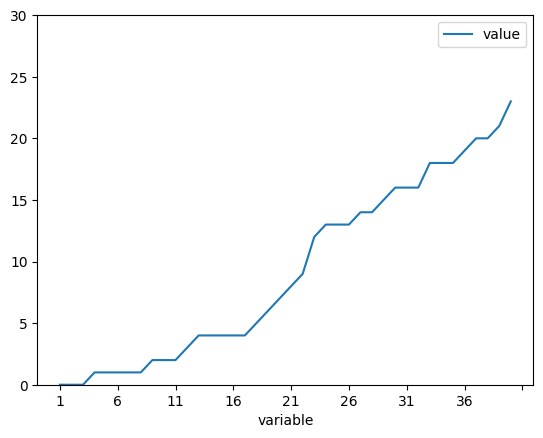

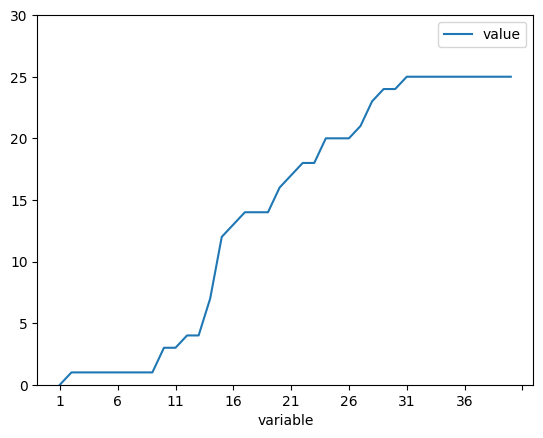

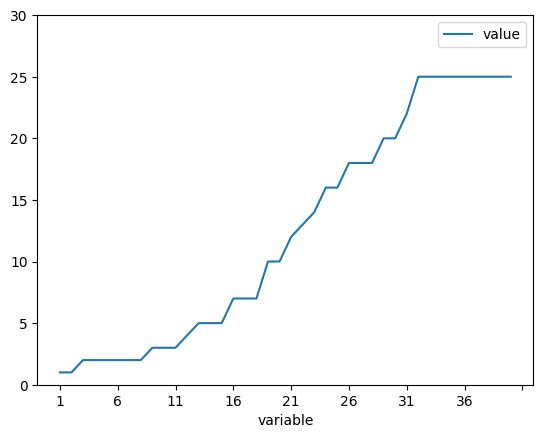

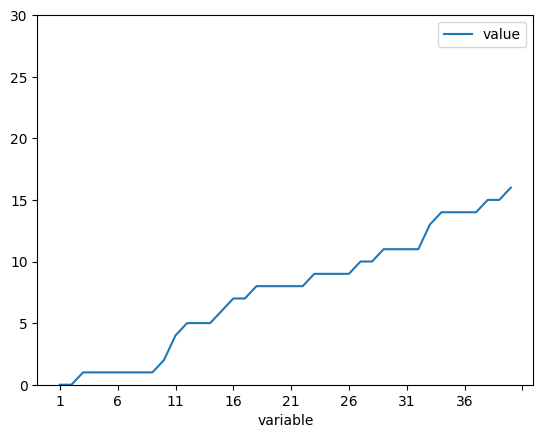

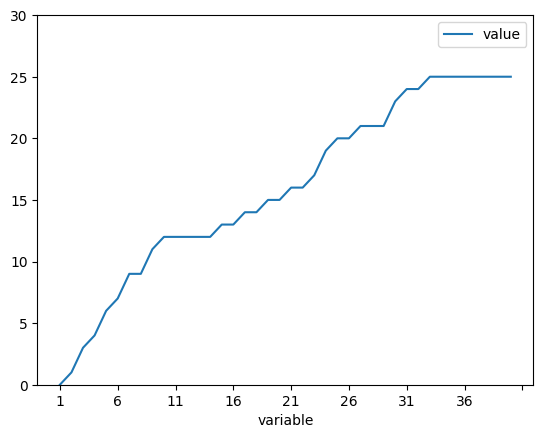

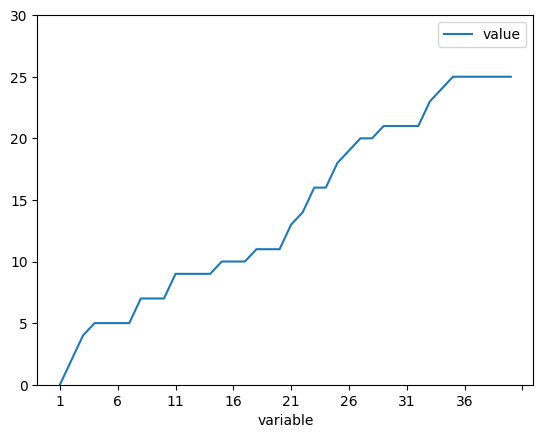

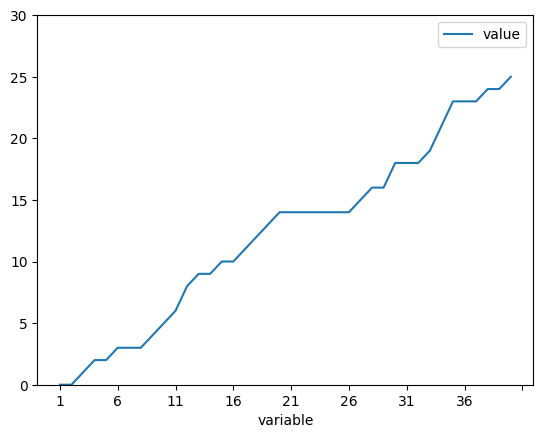

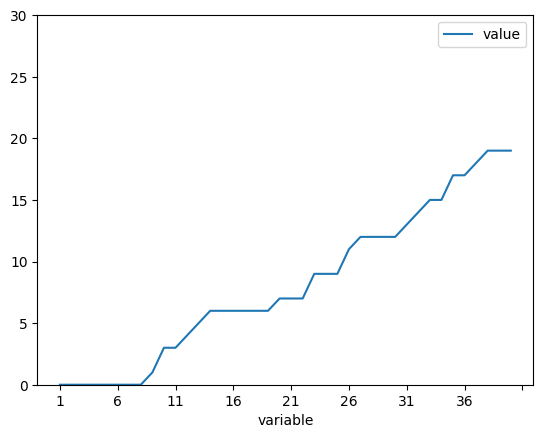

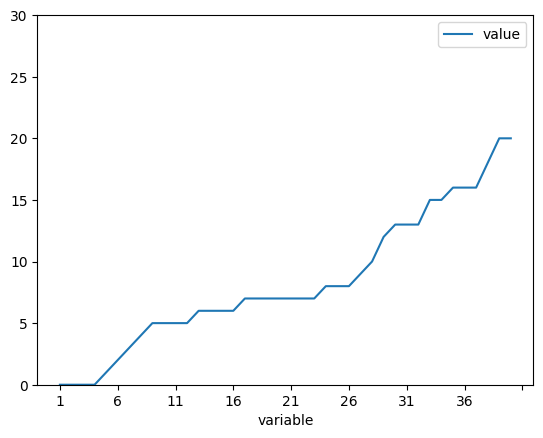

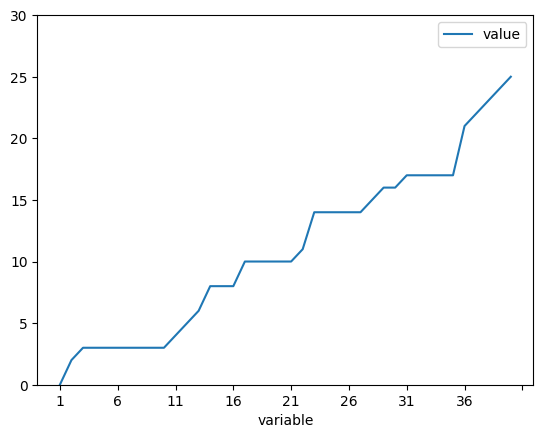

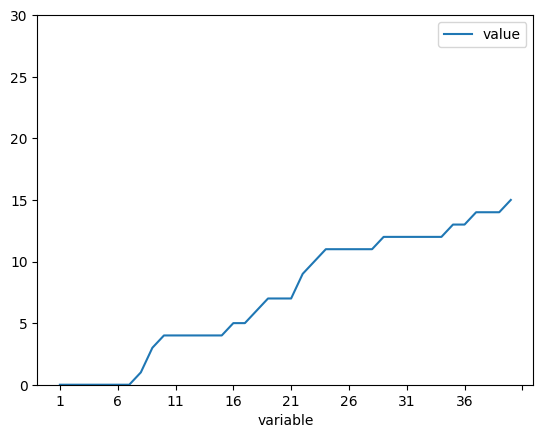

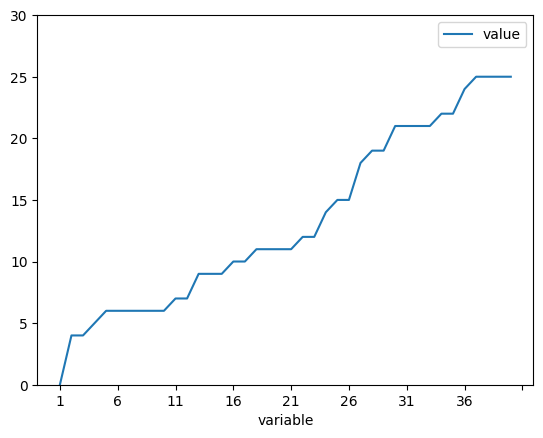

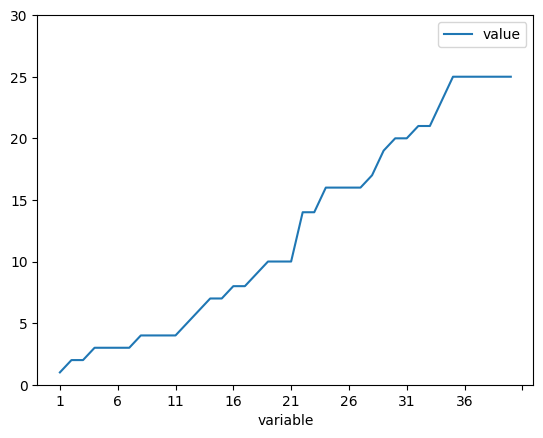

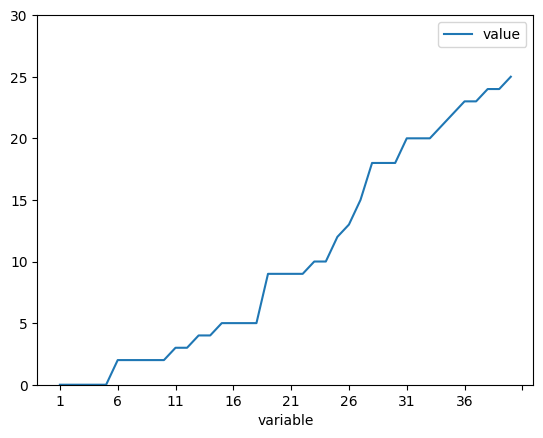

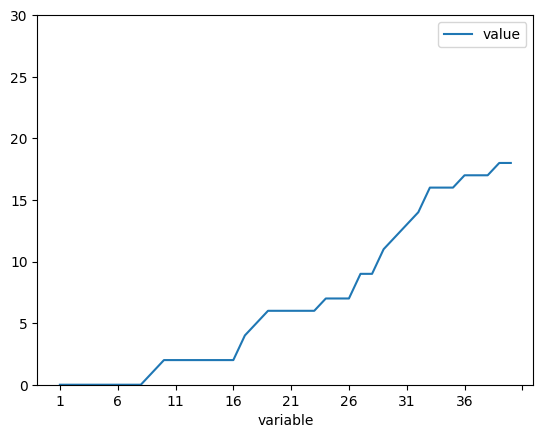

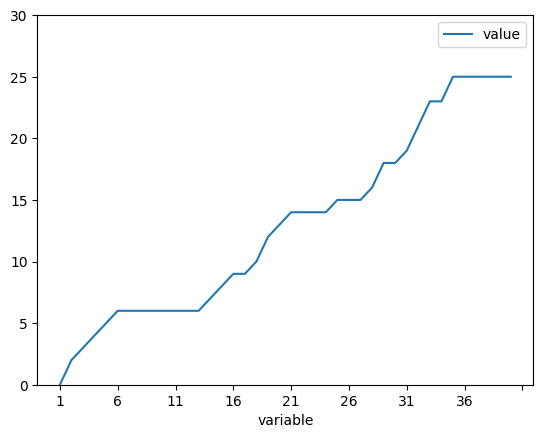

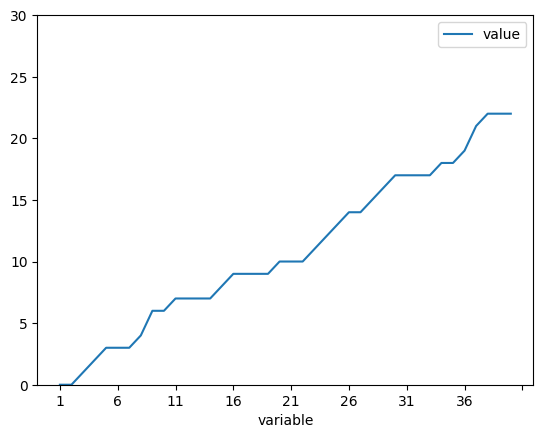

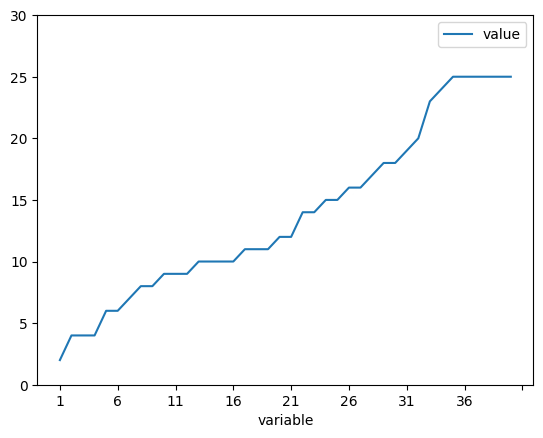

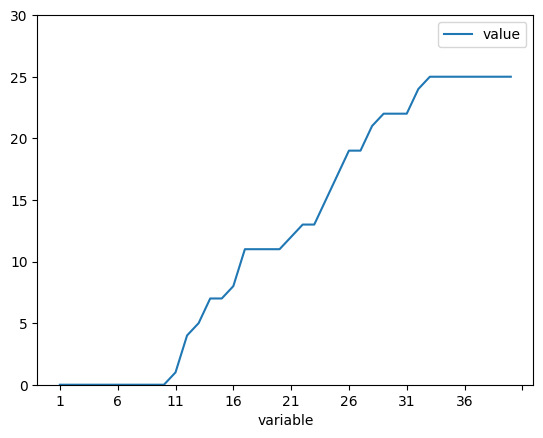

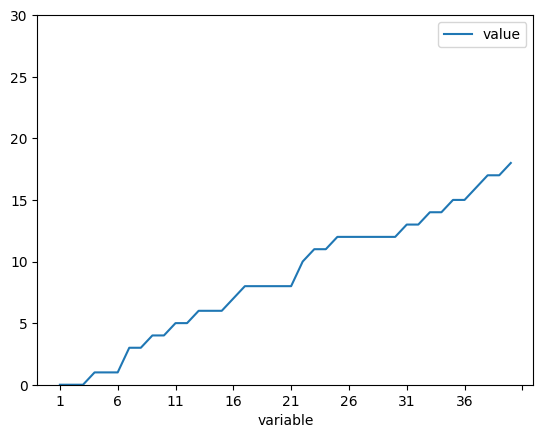

In [171]:
# Eyeball the data (^_^)
df_booking_ = df_booking.reset_index()
df_booking_ = pd.melt(df_booking_, id_vars=['index'])
booking_plot = df_booking_.groupby('index').plot(x='variable', y='value', kind='line', ylim=(0,30))

In [172]:
df_booking

,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
1,0,0,0,1,1,1,1,1,2,2,...,16,16,18,18,18,19,20,20,21,23
2,0,1,1,1,1,1,1,1,1,3,...,25,25,25,25,25,25,25,25,25,25
3,1,1,2,2,2,2,2,2,3,3,...,22,25,25,25,25,25,25,25,25,25
4,0,0,1,1,1,1,1,1,1,2,...,11,11,13,14,14,14,14,15,15,16
5,0,1,3,4,6,7,9,9,11,12,...,24,24,25,25,25,25,25,25,25,25
6,0,2,4,5,5,5,5,7,7,7,...,21,21,23,24,25,25,25,25,25,25
7,0,0,1,2,2,3,3,3,4,5,...,18,18,19,21,23,23,23,24,24,25
8,0,0,0,0,0,0,0,0,1,3,...,13,14,15,15,17,17,18,19,19,19
9,0,0,0,0,1,2,3,4,5,5,...,13,13,15,15,16,16,16,18,20,20
10,0,2,3,3,3,3,3,3,3,3,...,17,17,17,17,17,21,22,23,24,25


In [173]:
# Replace out of stock days with np.nan
df_booking = df_booking.replace(25,np.nan)
df_booking

,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
1,0,0,0,1,1,1,1,1,2,2,...,16.0,16.0,18.0,18.0,18.0,19.0,20.0,20.0,21.0,23.0
2,0,1,1,1,1,1,1,1,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1,2,2,2,2,2,2,3,3,...,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0,1,1,1,1,1,1,1,2,...,11.0,11.0,13.0,14.0,14.0,14.0,14.0,15.0,15.0,16.0
5,0,1,3,4,6,7,9,9,11,12,...,24.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0,2,4,5,5,5,5,7,7,7,...,21.0,21.0,23.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
7,0,0,1,2,2,3,3,3,4,5,...,18.0,18.0,19.0,21.0,23.0,23.0,23.0,24.0,24.0,NaN
8,0,0,0,0,0,0,0,0,1,3,...,13.0,14.0,15.0,15.0,17.0,17.0,18.0,19.0,19.0,19.0
9,0,0,0,0,1,2,3,4,5,5,...,13.0,13.0,15.0,15.0,16.0,16.0,16.0,18.0,20.0,20.0
10,0,2,3,3,3,3,3,3,3,3,...,17.0,17.0,17.0,17.0,17.0,21.0,22.0,23.0,24.0,NaN


In [174]:
# Get the day where demand becomes censored
df_count = df_booking.count(axis=1)
df_count

1     40
2     30
3     31
4     40
5     32
6     34
7     39
8     40
9     40
10    39
11    40
12    36
13    34
14    39
15    40
16    34
17    40
18    34
19    32
20    40
dtype: int64

In [175]:
for i in range(1,21):
    if df_booking.isnull().any(axis = 1).loc[i]: # with or without = True makes no difference
        df_booking.loc[i,df_count[i]] = np.nan

In [177]:
df_count

1     40
2     30
3     31
4     40
5     32
6     34
7     39
8     40
9     40
10    39
11    40
12    36
13    34
14    39
15    40
16    34
17    40
18    34
19    32
20    40
dtype: int64

In [180]:
df_booking

,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
1,0,0,0,1,1,1,1,1,2,2,...,16.0,16.0,18.0,18.0,18.0,19.0,20.0,20.0,21.0,23.0
2,0,1,1,1,1,1,1,1,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1,2,2,2,2,2,2,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0,1,1,1,1,1,1,1,2,...,11.0,11.0,13.0,14.0,14.0,14.0,14.0,15.0,15.0,16.0
5,0,1,3,4,6,7,9,9,11,12,...,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0,2,4,5,5,5,5,7,7,7,...,21.0,21.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0,0,1,2,2,3,3,3,4,5,...,18.0,18.0,19.0,21.0,23.0,23.0,23.0,24.0,NaN,NaN
8,0,0,0,0,0,0,0,0,1,3,...,13.0,14.0,15.0,15.0,17.0,17.0,18.0,19.0,19.0,19.0
9,0,0,0,0,1,2,3,4,5,5,...,13.0,13.0,15.0,15.0,16.0,16.0,16.0,18.0,20.0,20.0
10,0,2,3,3,3,3,3,3,3,3,...,17.0,17.0,17.0,17.0,17.0,21.0,22.0,23.0,NaN,NaN


In [186]:
# STEP 1: calculate hourly cumulative demand 

# Cumulative demand is already done, save DF of daily booking demand to calculate ratios
df_booking_daily = df_booking.diff(axis=1)
df_booking_daily[1] = df_booking[1]
df_booking_daily

,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
1,0,0,0,1,0,0,0,0,1,0,...,0.0,0.0,2.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0
2,0,1,0,0,0,0,0,0,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0,1,0,0,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0,1,0,0,0,0,0,0,1,...,0.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
5,0,1,2,1,2,1,2,0,2,1,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0,2,2,1,0,0,0,2,0,0,...,0.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0,0,1,1,0,1,0,0,1,1,...,0.0,0.0,1.0,2.0,2.0,0.0,0.0,1.0,NaN,NaN
8,0,0,0,0,0,0,0,0,1,2,...,1.0,1.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,0.0
9,0,0,0,0,1,1,1,1,1,0,...,0.0,0.0,2.0,0.0,1.0,0.0,0.0,2.0,2.0,0.0
10,0,2,1,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,4.0,1.0,1.0,NaN,NaN


In [ ]:
# STEP 2: Daily demand to cumulative demand ratio (r)
df_ratios = round(df_booking_daily/ df_booking,3)
df_ratios

,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
1,NaN,NaN,NaN,1.000,0.000,0.000,0.000,0.000,0.500,0.000,...,0.000,0.000,0.111,0.000,0.000,0.053,0.050,0.000,0.048,0.087
2,NaN,1.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,0.0,0.500,0.000,0.000,0.000,0.000,0.000,0.333,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,...,0.000,0.000,0.154,0.071,0.000,0.000,0.000,0.067,0.000,0.062
5,NaN,1.0,0.667,0.250,0.333,0.143,0.222,0.000,0.182,0.083,...,0.042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,1.0,0.500,0.200,0.000,0.000,0.000,0.286,0.000,0.000,...,0.000,0.000,0.087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,1.000,0.500,0.000,0.333,0.000,0.000,0.250,0.200,...,0.000,0.000,0.053,0.095,0.087,0.000,0.000,0.042,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.667,...,0.077,0.071,0.067,0.000,0.118,0.000,0.056,0.053,0.000,0.000
9,NaN,NaN,NaN,NaN,1.000,0.500,0.333,0.250,0.200,0.000,...,0.000,0.000,0.133,0.000,0.062,0.000,0.000,0.111,0.100,0.000
10,NaN,1.0,0.333,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.059,0.000,0.000,0.000,0.000,0.190,0.045,0.043,NaN,NaN


In [188]:
# STEP 3: calculate the average ratios for each day
df_average_ratios = np.nanmean(df_ratios, axis=0).round(3)
df_average_ratios

array([1.   , 0.778, 0.444, 0.302, 0.158, 0.134, 0.085, 0.127, 0.248,
       0.157, 0.148, 0.134, 0.11 , 0.071, 0.066, 0.071, 0.078, 0.058,
       0.082, 0.037, 0.036, 0.071, 0.072, 0.066, 0.037, 0.033, 0.055,
       0.044, 0.061, 0.033, 0.03 , 0.021, 0.064, 0.026, 0.038, 0.036,
       0.034, 0.042, 0.026, 0.034])

In [190]:
# STEP 4: calculate R (cumulative/total) and Q (hourly/total)
# applying initial values for R_m and Q_m before recursive calculations
# R_m = 1
# Q_m = r_m, where m is the last hourly interval of the day
array_R = np.ones(len(df_average_ratios))
array_Q = np.ones(len(df_average_ratios))

In [194]:
# Q_16 = r_16 
array_Q[39] = df_average_ratios[39]

In [ ]:
# calculate the R and Q backwardly
# remember that numpy array index starts from 0. so index = 15 is for hour = 16
# applying formulas to fill out remaining values
# R_i-1 = R_i - Q_i
# Q_i-1 = r_i-1 * R_i-1
for j in range(len(df_average_ratios)-2,-1,-1):
    array_R[j] = array_R[j+1] - array_Q[j+1]
    array_Q[j] = df_average_ratios[j]*array_R[j]

In [200]:
array_R

array([0.00535936, 0.02414125, 0.04341951, 0.0622056 , 0.07387839,
       0.08530992, 0.09323488, 0.10679826, 0.14201897, 0.16846853,
       0.19773301, 0.22832911, 0.25654956, 0.27615669, 0.29567097,
       0.318268  , 0.34519306, 0.36644699, 0.39917972, 0.41451685,
       0.42999673, 0.46285977, 0.49877131, 0.53401639, 0.55453415,
       0.57345827, 0.60683415, 0.63476376, 0.67599974, 0.69906902,
       0.72068971, 0.73614884, 0.7864838 , 0.80747823, 0.83937446,
       0.8707204 , 0.90136687, 0.940884  , 0.966     , 1.        ])

In [201]:
array_Q

array([0.00535936, 0.01878189, 0.01927826, 0.01878609, 0.01167279,
       0.01143153, 0.00792497, 0.01356338, 0.0352207 , 0.02644956,
       0.02926449, 0.0305961 , 0.02822045, 0.01960712, 0.01951428,
       0.02259703, 0.02692506, 0.02125393, 0.03273274, 0.01533712,
       0.01547988, 0.03286304, 0.03591153, 0.03524508, 0.02051776,
       0.01892412, 0.03337588, 0.02792961, 0.04123598, 0.02306928,
       0.02162069, 0.01545913, 0.05033496, 0.02099443, 0.03189623,
       0.03134593, 0.03064647, 0.03951713, 0.025116  , 0.034     ])

In [ ]:
# STEP 5: unconstrained total demand = last unconstrainted cumulative demand / R ratio
# modify the df_count series to indicate the position of last unconstrained cum. demand
df_count[df_count != 40] = df_count[df_count != 40] - 1 # 1 position before the value in df_count = first unconstrainted day
df_booking['position'] = df_count

# Check position
df_booking

,1,2,3,4,5,6,7,8,9,10,...,32,33,34,35,36,37,38,39,40,position
1,0,0,0,1,1,1,1,1,2,2,...,16.0,18.0,18.0,18.0,19.0,20.0,20.0,21.0,23.0,40
2,0,1,1,1,1,1,1,1,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29
3,1,1,2,2,2,2,2,2,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30
4,0,0,1,1,1,1,1,1,1,2,...,11.0,13.0,14.0,14.0,14.0,14.0,15.0,15.0,16.0,40
5,0,1,3,4,6,7,9,9,11,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31
6,0,2,4,5,5,5,5,7,7,7,...,21.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33
7,0,0,1,2,2,3,3,3,4,5,...,18.0,19.0,21.0,23.0,23.0,23.0,24.0,NaN,NaN,38
8,0,0,0,0,0,0,0,0,1,3,...,14.0,15.0,15.0,17.0,17.0,18.0,19.0,19.0,19.0,40
9,0,0,0,0,1,2,3,4,5,5,...,13.0,15.0,15.0,16.0,16.0,16.0,18.0,20.0,20.0,40
10,0,2,3,3,3,3,3,3,3,3,...,17.0,17.0,17.0,17.0,21.0,22.0,23.0,NaN,NaN,38


In [ ]:
# Extract last cumulative demand using the diagonal trick
df_booking['last_cum_demand'] = np.diag(df_booking.iloc[:,df_booking.position-1])

# R ratio for the position
df_booking['R'] = array_R[df_booking.position-1]

# calculate and store unconstrained total demand by proportional method
df_booking['prop'] = (df_booking['last_cum_demand']/df_booking['R']).round()

In [199]:
# Check outputs of proportional method
df_booking

,1,2,3,4,5,6,7,8,9,10,...,35,36,37,38,39,40,position,last_cum_demand,R,prop
1,0,0,0,1,1,1,1,1,2,2,...,18.0,19.0,20.0,20.0,21.0,23.0,40,23.0,1.000000,23.0
2,0,1,1,1,1,1,1,1,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,29,24.0,0.676000,36.0
3,1,1,2,2,2,2,2,2,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,30,20.0,0.699069,29.0
4,0,0,1,1,1,1,1,1,1,2,...,14.0,14.0,14.0,15.0,15.0,16.0,40,16.0,1.000000,16.0
5,0,1,3,4,6,7,9,9,11,12,...,NaN,NaN,NaN,NaN,NaN,NaN,31,24.0,0.720690,33.0
6,0,2,4,5,5,5,5,7,7,7,...,NaN,NaN,NaN,NaN,NaN,NaN,33,23.0,0.786484,29.0
7,0,0,1,2,2,3,3,3,4,5,...,23.0,23.0,23.0,24.0,NaN,NaN,38,24.0,0.940884,26.0
8,0,0,0,0,0,0,0,0,1,3,...,17.0,17.0,18.0,19.0,19.0,19.0,40,19.0,1.000000,19.0
9,0,0,0,0,1,2,3,4,5,5,...,16.0,16.0,16.0,18.0,20.0,20.0,40,20.0,1.000000,20.0
10,0,2,3,3,3,3,3,3,3,3,...,17.0,21.0,22.0,23.0,NaN,NaN,38,23.0,0.940884,24.0


The final numbers for this method (the values in column "prop") indicate our forecast for that particular booking instance (in this example, a 40-day booking period for the Hyatt) assuming demand were unconstrained. This number was reached by taking the final day in the period where demand was unconstrained (marked by the column "position", which has the index in the row of the column with the value for the final unconstrained cumulative demand) and the value in column "R". 

The value in R essentially tries to quantify how much of the total cumulative demand across all our measured periods is attributed to a certain day, with the final day being equal to 1 since it always has the full amount of cumulative demand. The further back across the days we go, the smaller R gets, since those days represent less of the proportion of cumulative demand (usually only having 0-2 rooms booked on these days). We use R to divide the final unconstrained demand value for a period/row with R to get our forecast of what demand would be for that period if we weren't limited to 25 rooms.

Since we are taking the operation of dividing a number by an increasingly smaller decimal the further back you go (R for day 1 < R for day 20 < R for day 40, etc), the earlier in a period the demand ceiling is reached, the greater the forecast will generally be, since R will be smaller. The amount R decreases at each step depends on how the cumulative demand changes on average across the various periods, which is why we take all the steps to calculate arrayQ and arrayR before, so we can properly weigh how much each day contributes to the total demand overall.

Using this, we get an estimate that is more aggressive the earlier in the period the demand ceiling was hit, but still takes into account the trends and patterns seen on the same day across all the periods.